# Phase 1 — Calibrating the gap Δ to q

This notebook maps the arm gap $\Delta = p_A - p_B$ to the per-agent discovery probability $q = P(D_i)$ by Monte Carlo, under both operational criteria of §1 (last-$k$ and posterior gap), holding the horizon $T$, the prior, and the criterion-tolerance *ratio* fixed. It produces a calibration curve $q(\Delta)$ and an **inverse** $\Delta(q)$, so a target such as $q = 0.05$ can be turned into the gap that realises it (or flagged as out of range).

The posterior-gap threshold is scaled per cell as $\delta = \Delta / 2$, strictly below the true gap, so that the criterion is asymptotically achievable ($q \to 1$ as $T \to \infty$) at every $\Delta$. Holding $\delta$ at a fixed absolute value would put low-$\Delta$ cells in the pathological regime $\delta > \Delta$, where $q$ collapses by finite-$T$ noise rather than tracking genuine discovery.

Arms are centered at $p_{\text{mid}} = 0.5$, with $p_A = p_{\text{mid}} + \Delta/2$ and $p_B = p_{\text{mid}} - \Delta/2$, so that $\Delta$ is the only true-gap quantity varying across the sweep.

**Restart-and-Run-All-safe.** The heavy sweep is wrapped in `%%time`; `tqdm` shows progress. Flip `SMOKE_TEST = True` for a fast end-to-end check.

## Setup

Local-only (no Colab/Drive). Imports from `model/` in the parent paper folder, exactly as the main Phase 1 notebook does.

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq
from tqdm.auto import tqdm

PAPER_ROOT = Path.cwd().resolve().parent
if str(PAPER_ROOT) not in sys.path:
    sys.path.insert(0, str(PAPER_ROOT))
RESULTS_DIR = PAPER_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

from model.bandit import ARM_A, ARM_B, BernoulliBandit
from model.discovery import discovered_by_last_k, discovered_by_posterior_gap
from model.simulation import run_simulation


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/ignacio/anaconda3/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/ignacio/anaconda3/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/ignacio/anaconda3/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/ignacio/anaconda3/lib/python3.10/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/ignacio/anaconda3/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/ignacio/anaconda3/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/ignacio/anaconda3/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/ignacio/anaconda3/lib/python3.10/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  

AttributeError: _ARRAY_API not found

## Parameters

Every knob in one cell. The calibration is *conditional* on these: a different horizon `N_STEPS`, prior, or criterion tolerance produces a different curve. The gap grid is denser at small $\Delta$, where $q$ changes fastest and where the floor lives.

In [ ]:
SMOKE_TEST = False         # True -> tiny run for kernel-restart smoke tests

# Arms are centered at P_MID and pulled apart by the gap Delta:
#   p_A = P_MID + Delta/2,  p_B = P_MID - Delta/2.
# Centering isolates Delta as the only thing that varies across the sweep.
P_MID = 0.5

# Monte Carlo budget. In the unaided regime every agent is an independent
# draw of D_i, so N_AGENTS is just the number of i.i.d. samples of q per gap.
N_AGENTS = 300 if SMOKE_TEST else 1500     # independent D_i samples per Delta
N_STEPS  = 80  if SMOKE_TEST else 200      # horizon T (held fixed across sweep)

# Gap grid. Delta must be > 0 (the bandit enforces p_A > p_B); the smallest
# values probe the q-floor as the arms become indistinguishable.
if SMOKE_TEST:
    DELTA_GRID = np.array([0.02, 0.05, 0.1, 0.2, 0.4])
else:
    DELTA_GRID = np.array([0.002, 0.005, 0.01, 0.02, 0.05,
                           0.1, 0.15, 0.2, 0.25, 0.3, 0.4])

# Discovery-criterion tolerances.
LAST_K_WINDOW = 20         # last-k: last k pulls all arm A
# Posterior-gap criterion threshold, computed per Delta inside the sweep as
#   delta = Delta * GAP_DELTA_FRACTION
# with the fraction held strictly below 1 so delta < Delta at every cell. This
# keeps the criterion asymptotically achievable (q -> 1 as T -> infinity).
# Holding delta fixed across the sweep would push low-Delta cells into the
# pathology where delta > Delta, in which q -> 0 by finite-T noise.
GAP_DELTA_FRACTION = 0.5

TARGET_Q    = 0.05         # the q we eventually want to hit by choosing Delta
MASTER_SEED = 2026

print(f'SMOKE_TEST={SMOKE_TEST}  n_agents/Delta={N_AGENTS}  n_steps={N_STEPS}  '
      f'#Delta={len(DELTA_GRID)}  gap_delta_fraction={GAP_DELTA_FRACTION}  '
      f'target_q={TARGET_Q}  seed={MASTER_SEED}')

## Discovery criteria (vectorized)

The two criteria are evaluated on every agent's final state at once. They are the vectorized forms of `discovered_by_last_k` and `discovered_by_posterior_gap` in [`model/discovery.py`](../model/discovery.py); the next cell asserts they agree with the per-agent module functions on a small sample, so the notebook can't drift from the definitions it reproduces.

In [3]:
def discovery_masks(histories, final_alpha_beta, *, k, delta):
    """Vectorized last-k and posterior-gap criteria over a whole community.

    histories:        (M, T, 2) int   rows [arm_pulled, outcome]
    final_alpha_beta: (M, 2, 2) float per-agent final Beta params
    Returns {criterion -> (M,) bool array of D_i outcomes}.
    """
    last_k = np.all(histories[:, -k:, 0] == ARM_A, axis=1)
    means = final_alpha_beta[:, :, 0] / final_alpha_beta.sum(axis=2)
    gap = (means[:, ARM_A] - means[:, ARM_B]) >= delta
    return {'last_k': last_k, 'posterior_gap': gap}

In [ ]:
# Cross-check the vectorized criteria against discovery.py's per-agent
# functions on a small sample, so this notebook cannot silently drift from
# the module definitions it is meant to reproduce.
_chk_gap = 0.6 - 0.4                                    # check bandit gap
_chk_delta = _chk_gap * GAP_DELTA_FRACTION              # delta < Delta for the check too
_chk = run_simulation(BernoulliBandit(p_a=0.6, p_b=0.4),
                      n_agents=50, n_steps=60, seed=0)
_vec = discovery_masks(_chk.histories, _chk.final_alpha_beta,
                       k=LAST_K_WINDOW, delta=_chk_delta)
_ref_lastk = np.array([
    discovered_by_last_k(_chk.histories[i], _chk.final_alpha_beta[i], k=LAST_K_WINDOW)
    for i in range(_chk.n_agents)])
_ref_gap = np.array([
    discovered_by_posterior_gap(_chk.histories[i], _chk.final_alpha_beta[i], delta=_chk_delta)
    for i in range(_chk.n_agents)])
assert np.array_equal(_vec['last_k'], _ref_lastk)
assert np.array_equal(_vec['posterior_gap'], _ref_gap)
print('vectorized criteria match discovery.py on the sample')

## Run the gap sweep

For each $\Delta$ we run one community of `N_AGENTS` independent agents (in the unaided regime every agent is an independent draw of $D_i$, so this is just `N_AGENTS` Monte Carlo samples of $q$) for `N_STEPS` steps, then record $\hat q$ and its binomial standard error under each criterion. Per-$\Delta$ seeds are spawned from `MASTER_SEED` so the whole sweep is reproducible.

In [ ]:
%%time
ss = np.random.SeedSequence(MASTER_SEED)
delta_seeds = [int(s.generate_state(1)[0]) for s in ss.spawn(len(DELTA_GRID))]

rows = []
for delta, seed in zip(tqdm(DELTA_GRID, desc='gap sweep'), delta_seeds):
    p_a = P_MID + delta / 2
    p_b = P_MID - delta / 2
    gap_delta = delta * GAP_DELTA_FRACTION              # delta < Delta per cell
    res = run_simulation(
        bandit=BernoulliBandit(p_a=p_a, p_b=p_b),
        n_agents=N_AGENTS, n_steps=N_STEPS, seed=seed,
    )
    masks = discovery_masks(res.histories, res.final_alpha_beta,
                            k=LAST_K_WINDOW, delta=gap_delta)
    for name, mask in masks.items():
        q = float(mask.mean())
        rows.append({
            'delta': float(delta), 'p_a': p_a, 'p_b': p_b,
            'gap_delta': gap_delta,
            'criterion': name, 'q_hat': q,
            'se': float(np.sqrt(q * (1 - q) / N_AGENTS)),
        })

calib = pd.DataFrame(rows)
calib_wide = calib.pivot(index='delta', columns='criterion', values='q_hat')
calib_wide

## The calibration curve $q(\Delta)$

figure -> results/phase1_gap_q_curve_20260530_182546.png


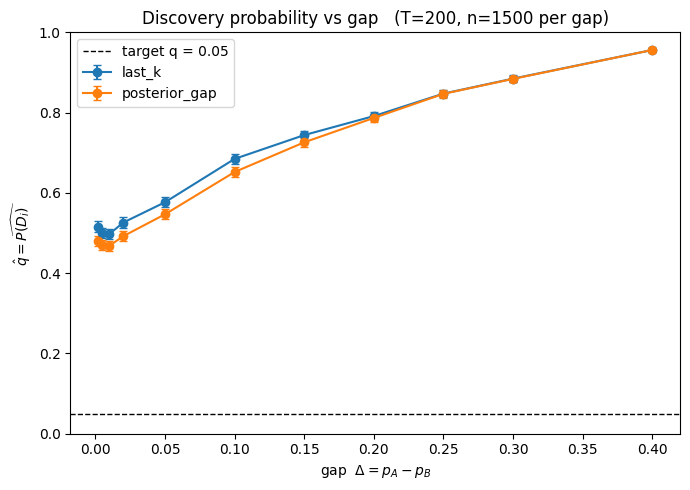

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, grp in calib.groupby('criterion'):
    ax.errorbar(grp['delta'], grp['q_hat'], yerr=grp['se'],
                marker='o', capsize=3, label=name)
ax.axhline(TARGET_Q, color='black', ls='--', lw=1, label=f'target q = {TARGET_Q}')
ax.set_xlabel(r'gap  $\Delta = p_A - p_B$')
ax.set_ylabel(r'$\hat q = \widehat{P(D_i)}$')
ax.set_title(f'Discovery probability vs gap   (T={N_STEPS}, n={N_AGENTS} per gap)')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
fig_path = RESULTS_DIR / f'phase1_gap_q_curve_{stamp}.png'
plt.savefig(fig_path, dpi=150)
print(f'figure -> {fig_path.relative_to(PAPER_ROOT)}')
plt.show()

## Invert: which Δ gives a target q?

We fit a monotone (PCHIP) interpolant $q(\Delta)$ per criterion and invert it by a bracketed root find. `delta_for_q(target)` returns the gap that realises `target`, or `None` if the target lies outside the range of $q$ spanned by the grid — in which case the printout reports the achievable interval, telling you which other knob (horizon or criterion tolerance) needs to move.

In [ ]:
def make_inverter(delta_grid, q_vals):
    """Return (delta_for_q, (q_min, q_max)) for one criterion.

    Monotone PCHIP interpolation of q(Delta); inversion by a bracketed root
    find that is robust to small Monte-Carlo non-monotonicity (it scans for
    the first sign change rather than trusting the endpoints).
    delta_for_q(target) -> the Delta giving q = target, or None when target
    is outside the achievable range [q_min, q_max] spanned by the grid.
    """
    order = np.argsort(delta_grid)
    d = np.asarray(delta_grid)[order]
    q = np.asarray(q_vals)[order]
    f = PchipInterpolator(d, q)
    q_min, q_max = float(q.min()), float(q.max())

    def delta_for_q(target):
        if not (q_min <= target <= q_max):
            return None
        g = lambda x: float(f(x)) - target
        xs = np.linspace(d[0], d[-1], 400)
        vals = np.array([g(x) for x in xs])
        crossings = np.where(np.diff(np.sign(vals)) != 0)[0]
        if len(crossings) == 0:
            return float(xs[np.argmin(np.abs(vals))])
        i = crossings[0]
        return float(brentq(g, xs[i], xs[i + 1]))

    return delta_for_q, (q_min, q_max)


print(f'Gap needed for q = {TARGET_Q}  '
      f'(T={N_STEPS}, k={LAST_K_WINDOW}, gap_delta = Delta * {GAP_DELTA_FRACTION}):')
print()

inverters = {}
for name, grp in calib.groupby('criterion'):
    inv, (q_min, q_max) = make_inverter(grp['delta'].values, grp['q_hat'].values)
    inverters[name] = inv
    d_star = inv(TARGET_Q)
    if d_star is None:
        print(f'  {name:14s}:  q stays in [{q_min:.3f}, {q_max:.3f}] over the grid; '
              f'q={TARGET_Q} is OUT OF RANGE (smallest gaps already give q~{q_min:.3f}).')
    else:
        print(f'  {name:14s}:  Delta ~ {d_star:.4f}   '
              f'(p_A~{P_MID + d_star / 2:.4f}, p_B~{P_MID - d_star / 2:.4f})')

## Save

Persist the calibration as a timestamped CSV under [`results/`](../results/) so the $\Delta \leftrightarrow q$ map can be reused later without recomputing.

In [8]:
stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
csv_path = RESULTS_DIR / f'phase1_gap_q_calibration_{stamp}.csv'
calib.to_csv(csv_path, index=False)
print(f'calibration table -> {csv_path.relative_to(PAPER_ROOT)}')
print(f'figure            -> {fig_path.relative_to(PAPER_ROOT)}')

calibration table -> results/phase1_gap_q_calibration_20260530_182546.csv
figure            -> results/phase1_gap_q_curve_20260530_182546.png


## What this shows, and how to use it

- **The relationship.** $\hat q$ rises monotonically with the gap $\Delta$ under both criteria, confirming the §2 claim that the gap is the primary driver of individual discovery. The curve is the systematic $\Delta \to q$ map; the inversion cell is the $q \to \Delta$ map you want for choosing parameters. The posterior-gap criterion is scaled per cell ($\delta = \Delta/2$), so both criteria are asymptotically achievable at every $\Delta$ in the grid.
- **Picking $\Delta$ for a target $q$.** Read it straight off the inversion cell (or, later, off the saved CSV): for any target $q$ in the achievable range, `delta_for_q(target)` returns the gap. Re-running this notebook is not needed once the CSV exists.
- **The floor.** As $\Delta \to 0$ the arms become indistinguishable and each criterion approaches a floor set by the agent's myopic commitment dynamics — for last-$k$ near $\tfrac12$, and for posterior-gap also near $\tfrac12$ once $\delta$ is scaled with $\Delta$ (in the limit $\Delta \to 0$ the criterion becomes "posterior mean of $A$ exceeds $B$ by any positive margin", which by symmetry fires on half of agents). If the inversion reports $q = 0.05$ **out of range**, that is the reason: at this horizon the criteria cannot make individuals that unsuccessful by gap alone. Two further levers are then (i) a **shorter horizon** `N_STEPS` (less time to settle lowers the whole curve) and (ii) a **stricter criterion** (larger $k$, or `GAP_DELTA_FRACTION` closer to 1 — but $\geq 1$ returns to the pathology where $\delta \geq \Delta$). Re-run with either changed to bring $0.05$ into range.